In [8]:
import torch
import numpy as np
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

In [9]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.10.0+cpu, Device: cpu


In [10]:
FEATURE_NUMS = 4        # 입력층으로 들어가는 데이터 개수 feature
SEQ_LENGTH = 5          # 정답을 만들기 위해 필요한 시점 개수 time step
HIDDEN_SIZE = 4         # RNN 계열 계층을 구성하는 hidden state 개수
NUM_LAYERS = 1          # RNN 계열 계층이 몇겹으로 쌓였는지 나타냄
LEARNING_RATE = 1e-3    # 학습율
BATCH_SIZE = 20         # 학습을 위한 배치사이즈 개수

In [11]:
pip install finance-datareader

     ---------------------------------------- 0.0/57.7 kB ? eta -:--:--
     ---------------------------------------- 57.7/57.7 kB 3.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/41.4 kB ? eta -:--:--
     ---------------------------------------- 41.4/41.4 kB ? eta 0:00:00
   ---------------------------------------- 0.0/51.3 kB ? eta -:--:--
   ---------------------------------------- 51.3/51.3 kB ? eta 0:00:00
   ---------------------------------------- 0.0/64.7 kB ? eta -:--:--
   ---------------------------------------- 64.7/64.7 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/107.7 kB ? eta -:--:--
   ---------------------------------------- 107.7/107.7 kB 6.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ------ --------------------------------- 0.7/4.0 MB 45.7 MB/s eta 0:00:01
   --------------- ------------------------ 1.5/4.0 MB 19.6 MB/s eta 0:00:01
   -------------------- ----------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import FinanceDataReader as fdr

df = fdr.DataReader('005930', '2020-01-01', '2024-06-30')

df = df[ ['Open', 'High', 'Low', 'Volume', 'Close'] ]
df = df.astype('float64')
df.head(10)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1108 entries, 2020-01-02 to 2024-06-28
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1108 non-null   float64
 1   High    1108 non-null   float64
 2   Low     1108 non-null   float64
 3   Volume  1108 non-null   float64
 4   Close   1108 non-null   float64
dtypes: float64(5)
memory usage: 51.9 KB


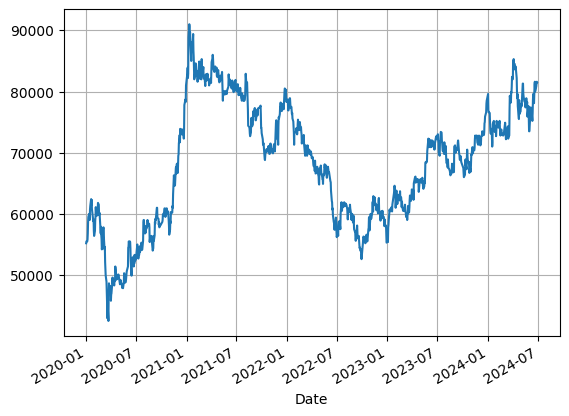

In [14]:
df['Close'].plot().grid()

In [30]:

# train : test - 70 : 30 분리

SPLIT = int(0.7*len(df))  # train : test = 7 : 3

train_df = df[ :SPLIT ]
test_df = df[ SPLIT: ]
# train_df = train_df.astype({train_df.columns[-1]: 'float64'})
# test_df = test_df.astype({test_df.columns[-1]: 'float64'})

In [26]:
train_df.info()
#scaler_x.fit_transform(train_df.iloc[ : , :-1 ])

<class 'pandas.DataFrame'>
DatetimeIndex: 775 entries, 2020-01-02 to 2023-02-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    775 non-null    int64  
 1   High    775 non-null    int64  
 2   Low     775 non-null    int64  
 3   Volume  775 non-null    int64  
 4   Close   775 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 36.3 KB


In [ ]:
scaler_x = MinMaxScaler()  # feature scaling

train_df.iloc[ : , :-1 ] = scaler_x.fit_transform(train_df.iloc[ : , :-1 ])
test_df.iloc[ : , :-1 ] = scaler_x.fit_transform(test_df.iloc[ : , :-1 ])

scaler_y = MinMaxScaler()  # label scaling

train_df.iloc[ : , -1 ] = scaler_y.fit_transform(train_df.iloc[ : , [-1] ])
test_df.iloc[ : , -1 ] = scaler_y.fit_transform(test_df.iloc[ : , [-1] ])

In [46]:
print(train_df.shape, test_df.shape)

(775, 5) (333, 5)


In [32]:
def MakeSeqNumpyData(data, seq_length):

    x_seq_list = []
    y_seq_list = []

    for i in range(len(data) - seq_length):
        x_seq_list.append(data[ i:i+seq_length, :-1 ])
        y_seq_list.append(data[ i+seq_length, [-1] ])

    x_seq_numpy = np.array(x_seq_list)
    y_seq_numpy = np.array(y_seq_list)

    return x_seq_numpy, y_seq_numpy

In [55]:
for i in range(len(np.array(train_df)) - SEQ_LENGTH):
    i+=1
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [56]:
x_train_data, y_train_data = MakeSeqNumpyData(np.array(train_df), SEQ_LENGTH)

x_test_data, y_test_data = MakeSeqNumpyData(np.array(test_df), SEQ_LENGTH)

print(x_train_data.shape, y_train_data.shape)
print(x_test_data.shape, y_test_data.shape)

(770, 5, 4) (770, 1)
(328, 5, 4) (328, 1)


In [57]:
x_train_tensor = torch.FloatTensor(x_train_data).to(DEVICE)
y_train_tensor = torch.FloatTensor(y_train_data).to(DEVICE)

x_test_tensor = torch.FloatTensor(x_test_data).to(DEVICE)
y_test_tensor = torch.FloatTensor(y_test_data).to(DEVICE)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)
     

In [58]:
class MyLSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, data):
        h0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)

        outputs, _ = self.lstm(data, (h0, c0))
        last_hs = outputs[:, -1, :]
        prediction = self.fc(last_hs)

        return prediction

In [59]:
model = MyLSTMModel(FEATURE_NUMS, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [60]:
def model_train(dataloader, model, loss_function, optimizer):

    model.train()

    train_loss_sum = 0

    total_train_batch = len(dataloader)

    for inputs, labels in dataloader:

        x_train = inputs.to(DEVICE)
        y_train = labels.to(DEVICE)

        outputs = model(x_train)
        loss = loss_function(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_avg_loss = train_loss_sum / total_train_batch

    return train_avg_loss

In [61]:
def model_evaluate(dataloader, model, loss_function, optimizer):

    model.eval()

    with torch.no_grad():

        val_loss_sum = 0

        total_val_batch = len(dataloader)

        for inputs, labels in dataloader:

            x_val = inputs.to(DEVICE)
            y_val = labels.to(DEVICE)

            outputs = model(x_val)
            loss = loss_function(outputs, y_val)

            val_loss_sum += loss.item()

        val_avg_loss = val_loss_sum / total_val_batch

    return val_avg_loss

In [62]:
from datetime import datetime

train_loss_list = []

start_time = datetime.now()

EPOCHS = 200

for epoch in range(EPOCHS):

    avg_loss = model_train(train_loader, model, loss_function, optimizer)

    train_loss_list.append(avg_loss)

    if (epoch % 10 == 0):
        print('epoch: ', epoch, ', train loss = ', avg_loss)

end_time = datetime.now()

print('elapsed time => ', end_time-start_time)

epoch:  0 , train loss =  0.25034458429003376
epoch:  10 , train loss =  0.011638561968142405
epoch:  20 , train loss =  0.0032087838365278468
epoch:  30 , train loss =  0.0021024044817283703
epoch:  40 , train loss =  0.0016922775789563998
epoch:  50 , train loss =  0.0014860245790213156
epoch:  60 , train loss =  0.0013563666412105353
epoch:  70 , train loss =  0.00126330163076114
epoch:  80 , train loss =  0.0011918002147024546
epoch:  90 , train loss =  0.001134723142455093
epoch:  100 , train loss =  0.0010879674112239184
epoch:  110 , train loss =  0.0010488790736790411
epoch:  120 , train loss =  0.0010155616932584403
epoch:  130 , train loss =  0.0009866097683791453
epoch:  140 , train loss =  0.000961003483658155
epoch:  150 , train loss =  0.0009380315582697781
epoch:  160 , train loss =  0.0009171853938217586
epoch:  170 , train loss =  0.0008981115160844264
epoch:  180 , train loss =  0.0008805305055247095
epoch:  190 , train loss =  0.0008642164958963314
elapsed time =>  0

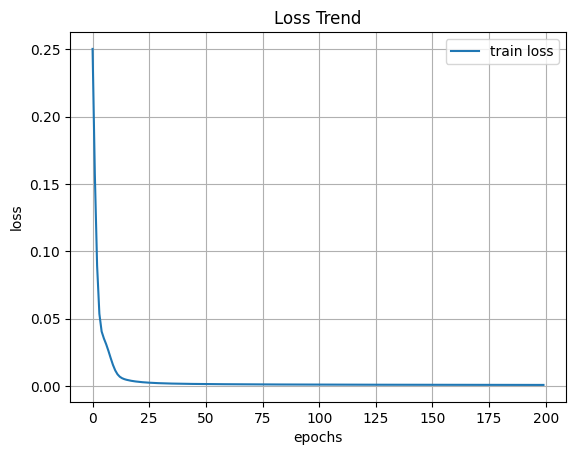

In [63]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(train_loss_list, label='train loss')
plt.legend()
plt.show()

In [64]:
test_pred_tensor = model(x_test_tensor)

test_pred_numpy = test_pred_tensor.cpu().detach().numpy()

pred_inverse = scaler_y.inverse_transform(test_pred_numpy)

y_test_numpy = y_test_tensor.cpu().detach().numpy()

y_test_inverse = scaler_y.inverse_transform(y_test_numpy)

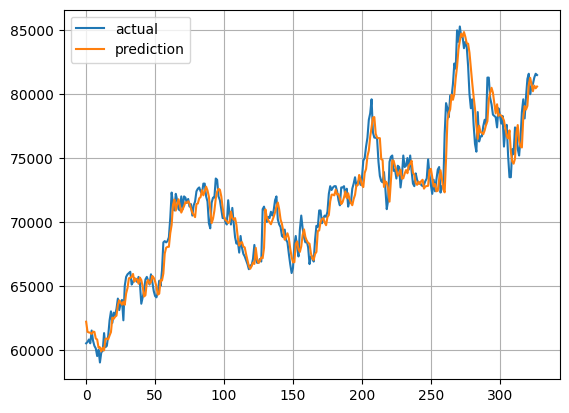

In [42]:
import matplotlib.pyplot as plt

plt.plot(y_test_inverse, label='actual')
plt.plot(pred_inverse, label='prediction')
plt.grid()
plt.legend()

plt.show()

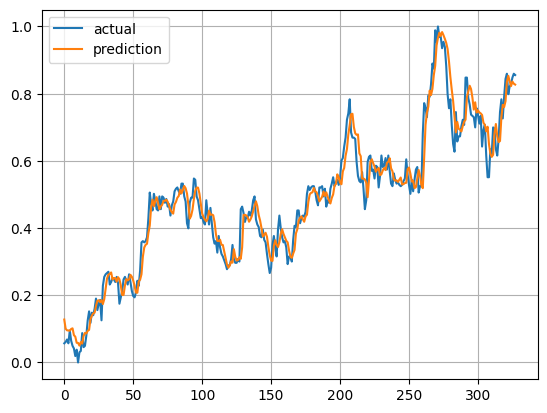

In [65]:
import matplotlib.pyplot as plt

plt.plot(y_test_numpy, label='actual')
plt.plot(test_pred_numpy, label='prediction')
plt.grid()
plt.legend()

plt.show()